# LightBoost

In [1]:
import pandas as pd 
import numpy as np 
import optuna
import joblib
import warnings

from sklearn.model_selection import train_test_split, KFold, cross_val_score 
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score 
from sklearn.preprocessing import OrdinalEncoder 
from lightgbm import LGBMRegressor 

# 2) SOPPRESSIONE WARNINGS
warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING) # Nasconde i log continui di Optuna
# Nota: imposteremo verbose=-1 in LightGBM per nascondere i suoi warning interni

def main():
    print("\n[1/6] Inizializzazione e caricamento dati...")
    X_wo_test = pd.read_csv("X_wo_test.csv")
    X_wo_train = pd.read_csv("X_wo_train.csv")
    y_wo_test = pd.read_csv("y_wo_test.csv").squeeze("columns")
    y_wo_train = pd.read_csv("y_wo_train.csv").squeeze("columns")

    # 4) RIMOZIONE COLONNA 'state' PRIMA DELL'ADDESTRAMENTO
    print("[2/6] Pulizia dei dati (Rimozione colonna 'state')...")
    if 'state' in X_wo_train.columns:
        X_wo_train = X_wo_train.drop(columns=['state'])
    if 'state' in X_wo_test.columns:
        X_wo_test = X_wo_test.drop(columns=['state'])

    print("[3/6] Encoding delle variabili categoriche...")
    # Colonne categoriche automatiche
    categorical_cols = X_wo_train.select_dtypes(include="object").columns 

    # Encoding 
    encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1) 
    X_wo_train[categorical_cols] = encoder.fit_transform(X_wo_train[categorical_cols]) 
    X_wo_test[categorical_cols] = encoder.transform(X_wo_test[categorical_cols]) 

    # OPTUNA OBJECTIVE
    def objective(trial):
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 500, 4000),
            "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
            "num_leaves": trial.suggest_int("num_leaves", 20, 300),
            "max_depth": trial.suggest_int("max_depth", -1, 20), # -1 è utile in LightGBM per nessun limite
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
            "random_state": 42,
            "verbose": -1 # Sopprime i warning di LightGBM
        }

        model = LGBMRegressor(**params)

        cv = KFold(n_splits=3, shuffle=True, random_state=42)

        scores = cross_val_score(
            model,
            X_wo_train,
            y_wo_train,
            scoring="neg_mean_absolute_error",
            cv=cv
        )

        return -scores.mean()

    # 3) STATO DI AVANZAMENTO: OPTUNA STUDY CON PROGRESS BAR
    print("[4/6] Avvio ottimizzazione iperparametri con Optuna (30 trials)...")
    study = optuna.create_study(direction="minimize")
    # show_progress_bar=True richiede la libreria 'tqdm' (pip install tqdm)
    study.optimize(objective, n_trials=30, show_progress_bar=True)

    # MODELLO FINALE CON PARAMETRI MIGLIORI
    print("[5/6] Addestramento del modello finale con i parametri ottimali...")
    best_params = study.best_params.copy()
    best_params["random_state"] = 42
    best_params["verbose"] = -1

    model = LGBMRegressor(**best_params)
    model.fit(X_wo_train, y_wo_train)

    # PREDIZIONE
    y_pred = model.predict(X_wo_test)

    # METRICHE FINALI E SALVATAGGIO
    print("[6/6] Calcolo delle metriche e salvataggio dei file...")
    mse = mean_squared_error(y_wo_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_wo_test, y_pred)
    r2 = r2_score(y_wo_test, y_pred)

    joblib.dump(model, "final_lightgbm_model.pkl")
    joblib.dump(encoder, "final_ordinal_encoder.pkl")

    print("\n" + "="*45)
    print(" RISULTATI FINALI DELL'ADDESTRAMENTO ")
    print("="*45)
    print(f"Miglior MAE in Cross-Validation : {study.best_value:.4f}")
    print("\nMigliori Iperparametri Trovati:")
    for key, value in study.best_params.items():
        print(f"  • {key}: {value}")
    
    print("\n" + "-"*45)
    print(" 📊 PRESTAZIONI SUL TEST SET 📊")
    print("-"*45)
    print(f"  • MAE  (Errore Medio Assoluto)  : {mae:.4f}")
    print(f"  • MSE  (Errore Quadratico Medio): {mse:.4f}")
    print(f"  • RMSE (Radice del MSE)         : {rmse:.4f}")
    print(f"  • R²   (Coefficiente Determin.) : {r2:.4f}")
    print("="*45)
    print("✅ Modello ed encoder salvati con successo!")
    print("Processo completato.\n")

if __name__ == "__main__":
    main()

c:\Users\rober\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



[1/6] Inizializzazione e caricamento dati...
[2/6] Pulizia dei dati (Rimozione colonna 'state')...
[3/6] Encoding delle variabili categoriche...
[4/6] Avvio ottimizzazione iperparametri con Optuna (30 trials)...


Best trial: 24. Best value: 1683.04: 100%|██████████| 30/30 [33:44<00:00, 67.48s/it]


[5/6] Addestramento del modello finale con i parametri ottimali...
[6/6] Calcolo delle metriche e salvataggio dei file...

 RISULTATI FINALI DELL'ADDESTRAMENTO 
Miglior MAE in Cross-Validation : 1683.0368

Migliori Iperparametri Trovati:
  • n_estimators: 3797
  • learning_rate: 0.06292466056391013
  • num_leaves: 269
  • max_depth: 15
  • subsample: 0.989471790837185
  • colsample_bytree: 0.6576566869746017
  • min_child_samples: 6

---------------------------------------------
 📊 PRESTAZIONI SUL TEST SET 📊
---------------------------------------------
  • MAE  (Errore Medio Assoluto)  : 1634.8794
  • MSE  (Errore Quadratico Medio): 11736716.9072
  • RMSE (Radice del MSE)         : 3425.8892
  • R²   (Coefficiente Determin.) : 0.9309
✅ Modello ed encoder salvati con successo!
Processo completato.



In [2]:
# richiamo dei modelli
model = joblib.load("final_lightgbm_model.pkl")
encoder = joblib.load("final_ordinal_encoder.pkl")

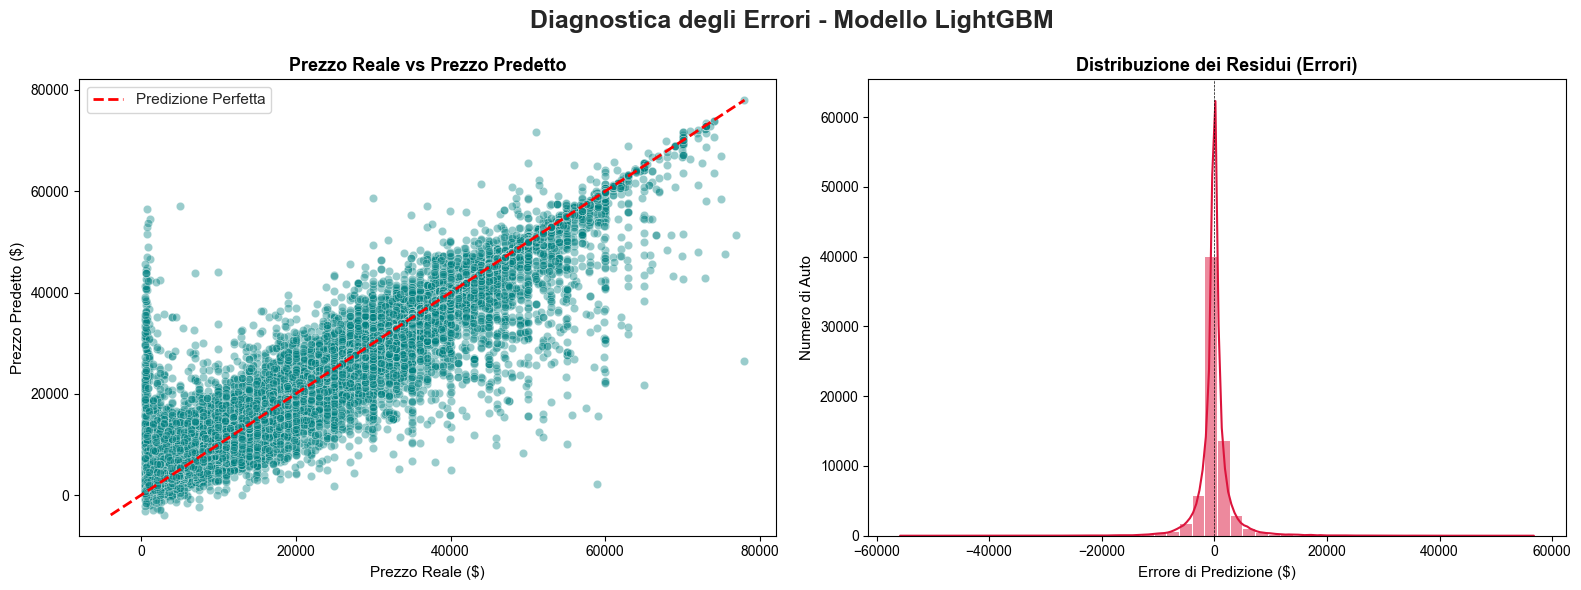


🔍 I 5 ERRORI PIÙ GRAVI DEL MODELLO (SOTTOSTIME O SOVRASTIME EPICHE):
       Reale      Predetto  Errore_Assoluto
44207  58988   2226.142476     56761.857524
64100    722  56530.799434     55808.799434
25990   1095  54481.263428     53386.263428
44000    833  53815.757377     52982.757377
40845    745  52853.970071     52108.970071


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# =========================================================================
# 1. CARICAMENTO MODELLI E DATI
# =========================================================================
# Richiamo dei modelli
model = joblib.load("final_lightgbm_model.pkl")
encoder = joblib.load("final_ordinal_encoder.pkl")

# Caricamento dei dati test
y_wo_test = pd.read_csv("y_wo_test.csv").squeeze("columns")
X_wo_test = pd.read_csv("X_wo_test.csv")

# Eliminiamo la colonna 'state' se per caso è rimasta nel CSV
if 'state' in X_wo_test.columns:
    X_wo_test = X_wo_test.drop(columns=['state'])

# =========================================================================
# 2. PREPROCESSING DEL TEST SET (IL VERO FIX)
# =========================================================================
# Invece di hackerare il booster, applichiamo semplicemente l'encoder
# che abbiamo salvato durante l'addestramento alle colonne testuali!

colonne_testuali = X_wo_test.select_dtypes(include=['object']).columns

if len(colonne_testuali) > 0:
    X_wo_test[colonne_testuali] = encoder.transform(X_wo_test[colonne_testuali])

# =========================================================================
# 3. PREDIZIONE E DIAGNOSTICA DEGLI ERRORI
# =========================================================================
# Creiamo la cartella "grafici" se non esiste già
os.makedirs('grafici', exist_ok=True)

# Predizione
y_pred = model.predict(X_wo_test)
residui = y_wo_test - y_pred

# Creiamo una figura con due grafici affiancati (1 riga, 2 colonne)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_theme(style="whitegrid")

# --- AGGIUNTA DEL TITOLO PRINCIPALE ---
fig.suptitle("Diagnostica degli Errori - Modello LightGBM", fontsize=18, fontweight='bold')

# -------------------------------------------------------------------------
# GRAFICO A: Prezzo Reale vs Prezzo Predetto
# -------------------------------------------------------------------------
sns.scatterplot(ax=axes[0], x=y_wo_test, y=y_pred, alpha=0.4, color='teal')

# Disegniamo la linea di "predizione perfetta" a 45 gradi
limiti = [min(y_wo_test.min(), y_pred.min()), max(y_wo_test.max(), y_pred.max())]
axes[0].plot(limiti, limiti, color='red', linestyle='--', linewidth=2, label='Predizione Perfetta')

axes[0].set_title("Prezzo Reale vs Prezzo Predetto", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Prezzo Reale ($)", fontsize=11)
axes[0].set_ylabel("Prezzo Predetto ($)", fontsize=11)
axes[0].legend()

# -------------------------------------------------------------------------
# GRAFICO B: Distribuzione degli Errori (Residui)
# -------------------------------------------------------------------------
sns.histplot(ax=axes[1], x=residui, kde=True, color='crimson', bins=50)

# Disegniamo la linea sullo zero (errore nullo)
axes[1].axvline(x=0, color='black', linestyle='--', linewidth=0.5)

axes[1].set_title("Distribuzione dei Residui (Errori)", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Errore di Predizione ($)", fontsize=11)
axes[1].set_ylabel("Numero di Auto", fontsize=11)

# Ottimizziamo gli spazi per evitare che il titolo principale si sovrapponga ai grafici
plt.tight_layout()

# Salviamo l'immagine in alta risoluzione (dpi=300) nella cartella "grafici"
plt.savefig('grafici/risultato_LightBoost.png', dpi=300, bbox_inches="tight")

# Mostriamo il grafico a schermo
plt.show()

# =========================================================================
# 4. ANALISI EXTRA: DOVE SBAGLIA DI PIÙ?
# =========================================================================
# Creiamo un piccolo DataFrame per isolare i casi peggiori
analisi_errori = pd.DataFrame({
    'Reale': y_wo_test,
    'Predetto': y_pred,
    'Errore_Assoluto': np.abs(residui)
}).sort_values(by='Errore_Assoluto', ascending=False)

print("\n" + "="*73)
print("🔍 I 5 ERRORI PIÙ GRAVI DEL MODELLO (SOTTOSTIME O SOVRASTIME EPICHE):")
print("="*73)
print(analisi_errori.head())
print("="*73)

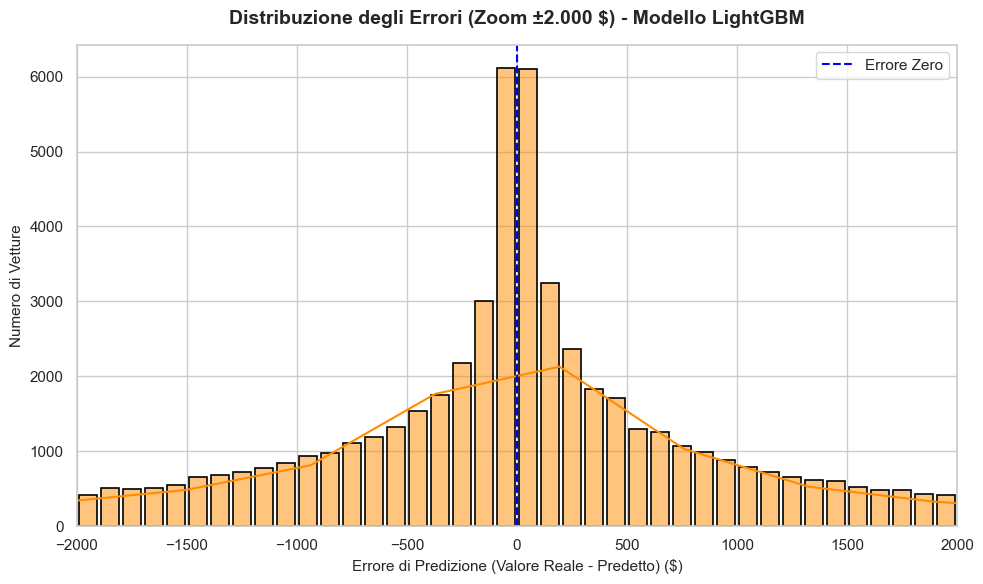


📊 ANALISI DI PRECISIONE NELLO ZOOM:
-> Il 76.9% delle auto nel test set viene predetto con un errore compreso tra -2000$ e +2000$.


In [4]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Creiamo la cartella "grafici" se non esiste già
os.makedirs('grafici', exist_ok=True)

# =========================================================================
# ISTOGRAMMA DEI RESIDUI ZOOMATO (TRA -2000$ E +2000$)
# =========================================================================

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Ottimizzato: calcoliamo i bin solo per l'area di interesse, con ampiezza 100$
sns.histplot(
    residui, 
    kde=True, 
    color='darkorange', 
    binrange=(-2000, 2000), 
    binwidth=100,           
    shrink=0.85,
    edgecolor='black',  
    linewidth=1.2       
)

# Applichiamo il limite richiesto sull'asse delle X
plt.xlim(-2000, 2000)

# Linea nera di riferimento sullo ZERO (il punto di predizione perfetta)
plt.axvline(x=0, color='blue', linestyle='--', linewidth=1.5, label='Errore Zero')

# Personalizzazione estetica (corretto il nome in LightGBM)
plt.title("Distribuzione degli Errori (Zoom ±2.000 $) - Modello LightGBM", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Errore di Predizione (Valore Reale - Predetto) ($)", fontsize=11)
plt.ylabel("Numero di Vetture", fontsize=11)
plt.legend()

plt.tight_layout()

# Salviamo l'immagine in alta risoluzione (dpi=300) nella cartella "grafici"
plt.savefig('grafici/istogramma_zoom_LightGBM.png', dpi=300, bbox_inches="tight")

# Mostriamo il grafico a schermo
plt.show()

# =========================================================================
# CALCOLO DELLA PERCENTUALE DI ERRORI IN QUESTA FASCIA
# =========================================================================
# Giusto per darti un dato numerico da spendere nella relazione/analisi:
auto_nella_fascia = ((residui >= -2000) & (residui <= 2000)).sum()
percentuale = (auto_nella_fascia / len(residui)) * 100

print(f"\n📊 ANALISI DI PRECISIONE NELLO ZOOM:")
print(f"-> Il {percentuale:.1f}% delle auto nel test set viene predetto con un errore compreso tra -2000$ e +2000$.")
print("=========================================================================")


MARCHE CON L'ERRORE MEDIO (MAE) PIÙ ALTO (Filtrate per min. 5 auto):
          marca auto_totali auto_sbagliate_piu_100 percentuale_errate_piu_100 mae_marca errore_percentuale_medio
        porsche         230                    188                      81.7% 4367.18 $                    14.4%
         datsun          12                     10                      83.3% 4281.72 $                    39.5%
harley-davidson          22                     20                      90.9% 3913.20 $                    31.4%
          rover         310                    251                      81.0% 3268.07 $                    11.7%
            ram       2,950                  2,286                      77.5% 2234.66 $                     7.3%
  mercedes-benz       1,878                  1,621                      86.3% 2137.73 $                    10.1%
            gmc       2,858                  2,245                      78.6% 2046.55 $                     8.3%
           ford      11,985

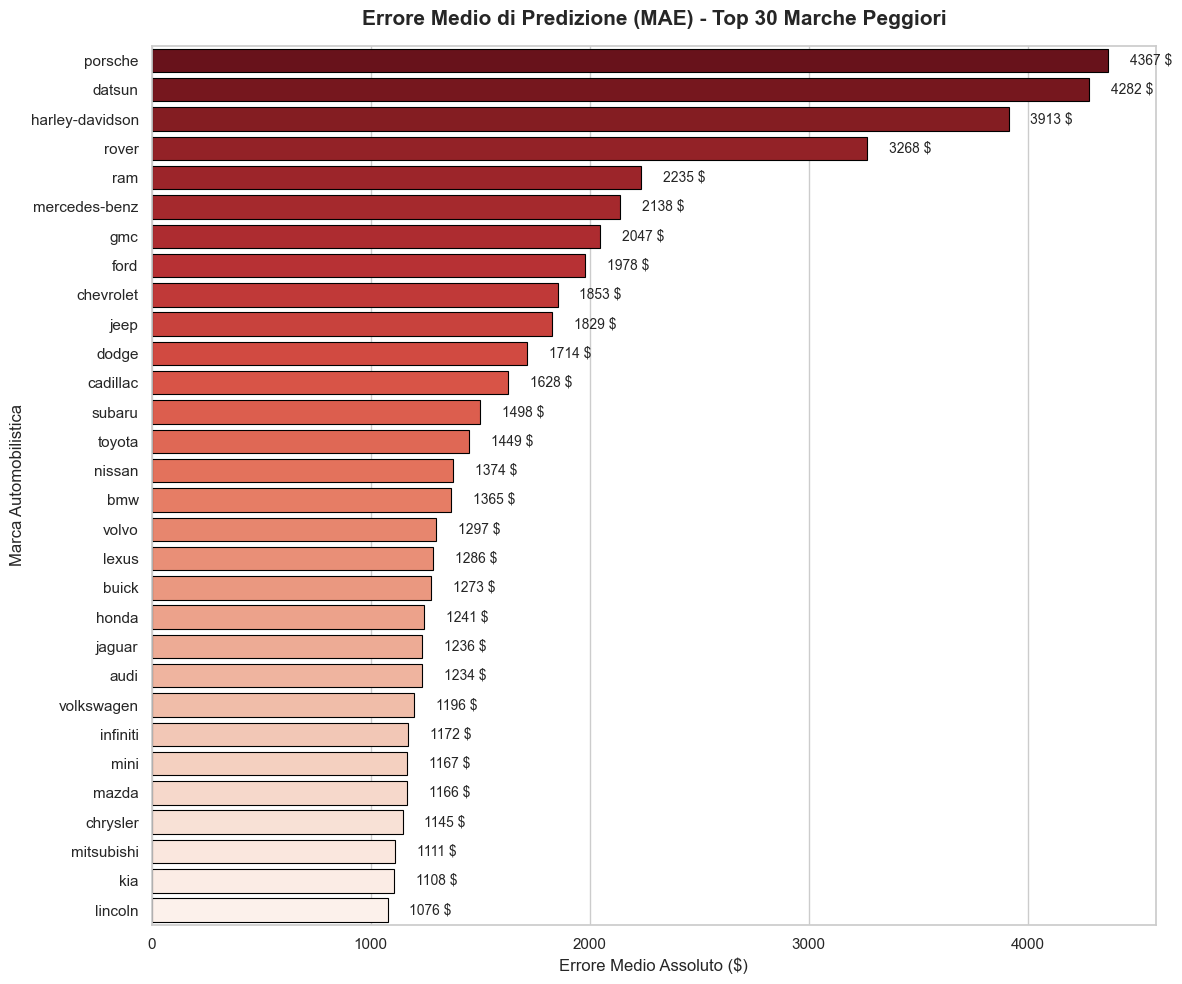

In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================================
# 1. RICOSTRUZIONE DELLE MARCHE ORIGINALI
# =========================================================================
# Il modo più semplice e sicuro per recuperare i nomi in formato testo 
# è rileggere la colonna direttamente dal CSV originale.
X_raw = pd.read_csv("X_wo_test.csv")

# Assumiamo che la colonna delle marche si chiami 'manufacturer' (o 'make')
colonna_marca = 'manufacturer' if 'manufacturer' in X_raw.columns else 'make'
marche_originali = X_raw[colonna_marca]

# Creiamo il DataFrame contenente i reali, i predetti e gli errori assoluti
df_errori = pd.DataFrame({
    'marca': marche_originali,
    'prezzo_reale': y_wo_test,
    'prezzo_predetto': y_pred,
    'errore_assoluto': np.abs(residui) # residui era stato calcolato precedentemente
})

# =========================================================================
# 2. AGGREGAZIONE E CALCOLO DELLE METRICHE PER MARCA
# =========================================================================
# Calcoliamo il MAE reale considerando TUTTE le auto di una determinata marca
analisi_marche = df_errori.groupby('marca').agg(
    auto_totali=('marca', 'count'),
    mae_marca=('errore_assoluto', 'mean'),
    prezzo_reale_medio=('prezzo_reale', 'mean')
).reset_index()

# Calcoliamo le auto con errore grave (es. > 100$) per mantenere la tua logica
errori_gravi = df_errori[df_errori['errore_assoluto'] > 100].groupby('marca').size().to_frame('auto_sbagliate_piu_100')
analisi_marche = analisi_marche.merge(errori_gravi, on='marca', how='left').fillna({'auto_sbagliate_piu_100': 0})

# Calcolo percentuali
analisi_marche['percentuale_errate_piu_100'] = (analisi_marche['auto_sbagliate_piu_100'] / analisi_marche['auto_totali']) * 100
analisi_marche['errore_percentuale_medio'] = (analisi_marche['mae_marca'] / analisi_marche['prezzo_reale_medio']) * 100

# FILTRO: escludiamo marche con troppo poche auto (es. meno di 5) 
# per evitare che 1 solo errore grave sballi l'intera classifica
analisi_marche = analisi_marche[analisi_marche['auto_totali'] >= 5]

# Ordiniamo la classifica in base al MAE peggiore
analisi_marche = analisi_marche.sort_values(by='mae_marca', ascending=False).reset_index(drop=True)

print("=====================================================================================================")
print("MARCHE CON L'ERRORE MEDIO (MAE) PIÙ ALTO (Filtrate per min. 5 auto):")
print("=====================================================================================================")
print(analisi_marche[['marca', 'auto_totali', 'auto_sbagliate_piu_100', 'percentuale_errate_piu_100', 'mae_marca', 'errore_percentuale_medio']].head(30).to_string(index=False, formatters={
    'auto_totali': '{:,.0f}'.format,
    'auto_sbagliate_piu_100': '{:,.0f}'.format,
    'percentuale_errate_piu_100': '{:.1f}%'.format,
    'mae_marca': '{:.2f} $'.format,
    'errore_percentuale_medio': '{:.1f}%'.format
}))
print("=====================================================================================================")

# =========================================================================
# 3. GRAFICO DEL MAE PER OGNI MARCA (DOVE SBAGLIA DI PIÙ?)
# =========================================================================
# Prendiamo solo le peggiori 30 marche per mantenere il grafico leggibile
dati_grafico = analisi_marche.head(30)

plt.figure(figsize=(12, 10))
sns.set_theme(style="whitegrid")

sns.barplot(
    x='mae_marca',
    y='marca',
    data=dati_grafico,
    palette='Reds_r',
    hue='marca',
    legend=False,
    edgecolor='black',
    linewidth=0.8
)

plt.title("Errore Medio di Predizione (MAE) - Top 30 Marche Peggiori", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Errore Medio Assoluto ($)", fontsize=12)
plt.ylabel("Marca Automobilistica", fontsize=12)

# Aggiungiamo i valori numerici alla fine di ogni barra per maggiore chiarezza
for index, value in enumerate(dati_grafico['mae_marca']):
    plt.text(value + 100, index, f"{value:.0f} $", va='center', fontsize=10)

plt.tight_layout()

# Creiamo la cartella e salviamo
os.makedirs('grafici', exist_ok=True)
plt.savefig('grafici/mae_per_marca_LightGBM.png', dpi=300, bbox_inches="tight")

plt.show()